# Explainable AI Framework for Identity Fraud Detection at Bank Account Opening
## Notebook 2 - Model Development and Evaluation

**Sydney Ndabai (P2929107)** · CSIP5402 · Supervisor: Ahmad Lawal · De Montfort University

Each model occupies one section containing a single training cell that performs tuning, training, validation, threshold calibration and test evaluation in sequence, followed by its confusion matrix. Models are compared in Section 8.

## 0. Setup

Imports libraries and fixes the global random seed for reproducibility.

In [1]:
import numpy as np
import pandas as pd
import random
import os
import time
import joblib
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn, xgboost, lightgbm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, average_precision_score,
                             precision_recall_curve, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, balanced_accuracy_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from itertools import product

os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for lib in [np, pd, sklearn, xgboost, lightgbm]:
    print(f"{lib.__name__:14s} {lib.__version__}")
print(f"{'SEED':14s} {SEED}")

numpy          2.0.2
pandas         2.3.3
sklearn        1.6.1
xgboost        3.2.0
lightgbm       4.6.0
SEED           42


### 0.1 Load Data

Loads the partitions and feature configuration from Notebook 1 and confirms the row counts and fraud rates, verifying the handoff.

In [2]:
NB1 = "/kaggle/input/notebooks/sydneyndabai/fyp-one"

train = pd.read_parquet(f"{NB1}/train.parquet")
val   = pd.read_parquet(f"{NB1}/val.parquet")
test  = pd.read_parquet(f"{NB1}/test.parquet")
cfg   = joblib.load(f"{NB1}/feature_config.pkl")

TARGET = cfg["TARGET"]
feature_cols = cfg["feature_cols"]
categorical_cols = cfg["categorical_cols"]
numeric_cols = cfg["numeric_cols"]

X_train, y_train = train[feature_cols], train[TARGET]
X_val,   y_val   = val[feature_cols],   val[TARGET]
X_test,  y_test  = test[feature_cols],  test[TARGET]
train_months = train["month"]

for nm, X, y in [("Train (0-5)", X_train, y_train), ("Val (6)", X_val, y_val), ("Test (7)", X_test, y_test)]:
    print(f"{nm:14s} {X.shape}   fraud_rate={y.mean():.4f}   fraud_cases={int(y.sum()):,}")
print(f"\nPredictors: {len(feature_cols)} ({len(categorical_cols)} categorical, {len(numeric_cols)} numeric)")

Train (0-5)    (794989, 35)   fraud_rate=0.0103   fraud_cases=8,151
Val (6)        (108168, 35)   fraud_rate=0.0134   fraud_cases=1,450
Test (7)       (96843, 35)   fraud_rate=0.0147   fraud_cases=1,428

Predictors: 35 (5 categorical, 30 numeric)


### 0.2 Preprocessing Pipelines

Two `ColumnTransformer` definitions are used. Both one-hot encode categorical features, while the linear-model pipeline additionally standardises numerical features to place them on comparable scales and support regularised Logistic Regression optimisation. Tree-based models retain numerical features on their original scales because tree splitting is not dependent on feature scaling.

All preprocessing is fitted inside the corresponding model pipelines using training data only, preventing validation or test statistics from influencing learned transformations.

In [3]:
preprocess_trees = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)],
    remainder="passthrough", verbose_feature_names_out=False,
)

preprocess_linear = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", StandardScaler(), numeric_cols),
    ],
    remainder="drop", verbose_feature_names_out=False,
)

print("preprocess_trees  : one-hot encoding, numeric unchanged")
print("preprocess_linear : one-hot encoding + standardisation")

preprocess_trees  : one-hot encoding, numeric unchanged
preprocess_linear : one-hot encoding + standardisation


### 0.3 Shared Functions

Defined once so every model is tuned, calibrated and scored identically.

`tune` performs walk-forward hyperparameter search *within the training window* (months 0–3 → 4, then 0–4 → 5), so no tuning decision touches validation or test. `run_model` executes the full per-model workflow train, calibrate the threshold on validation at 5% FPR, freeze it, evaluate once on test, and returns the complete metric set.

**Metric classification.** Threshold-free metrics (ROC-AUC, PR-AUC) measure ranking quality independently of any cut-off. Threshold-dependent metrics (precision, recall, F1, accuracy, balanced accuracy) describe behaviour at the deployed cut-off. TPR at 5% FPR is primary: it is the BAF authors' operating point and reflects finite manual-review capacity.

In [4]:
WF_FOLDS = [([0, 1, 2, 3], 4), ([0, 1, 2, 3, 4], 5)]
results, val_scores_store, test_scores_store, fitted_models, thresholds = (
    [],
    {},
    {},
    {},
    {},
)


def threshold_at_fpr(y_true, scores, target_fpr=0.05):
  """Calculates probability threshold closest to target FPR on provided set."""
  fpr, tpr, thr = roc_curve(y_true, scores)
  i = int(np.argmin(np.abs(fpr - target_fpr)))
  return float(thr[i]), float(fpr[i]), float(tpr[i])


def tune(name, grid, build_fn):
  """Walk-forward hyperparameter tuning evaluated using PR-AUC (rank-based, leakage-free)."""
  keys, combos = list(grid.keys()), list(product(*grid.values()))
  print(f"[{name}] tuning {len(combos)} configurations via walk-forward validation")
  rows = []

  for combo in combos:
    params = dict(zip(keys, combo))
    fold_scores = []

    for tr_m, va_m in WF_FOLDS:
      tr, va = train_months.isin(tr_m), train_months == va_m
      m = clone(build_fn(params))
      m.fit(X_train[tr], y_train[tr])
      preds = m.predict_proba(X_train[va])[:, 1]
      # Using PR-AUC for hyperparameter selection to prevent threshold leakage
      fold_scores.append(average_precision_score(y_train[va], preds))

    score = float(np.mean(fold_scores))
    rows.append({**params, "wf_pr_auc": score})
    print(
        "   "
        + "  ".join(f"{k}={v}" for k, v in params.items())
        + f"  -> PR-AUC: {score:.4f}"
    )

  df = (
      pd.DataFrame(rows)
      .sort_values("wf_pr_auc", ascending=False)
      .reset_index(drop=True)
  )
  print(f"   BEST: {df.iloc[0].to_dict()}\n")
  return df


def run_model(name, pipeline):
  """Fits pipeline, freezes decision threshold at 5% FPR on validation set, and evaluates on test set."""
  t0 = time.time()
  pipeline.fit(X_train, y_train)
  train_time = time.time() - t0
  print(f"[{name}] trained on {len(X_train):,} rows in {train_time:.1f}s")

  # 1. Freeze decision threshold on validation set at target FPR (5%)
  v = pipeline.predict_proba(X_val)[:, 1]
  thr, v_fpr, v_tpr = threshold_at_fpr(y_val, v, 0.05)
  print(
      f"[{name}] validation: score range [{v.min():.4f}, {v.max():.4f}] | "
      f"threshold {thr:.4f} frozen at FPR {v_fpr:.4f}, TPR {v_tpr:.4f}"
  )

  # 2. Evaluate frozen threshold on test set
  s = pipeline.predict_proba(X_test)[:, 1]
  pred = (s >= thr).astype(int)
  tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
  fg, tg, _ = roc_curve(y_test, s)

  row = {
      "Model": name,
      "TPR@5%FPR": round(float(np.interp(0.05, fg, tg)), 4),
      "PR-AUC": round(average_precision_score(y_test, s), 4),
      "ROC-AUC": round(roc_auc_score(y_test, s), 4),
      "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
      "Recall": round(recall_score(y_test, pred, zero_division=0), 4),
      "F1": round(f1_score(y_test, pred, zero_division=0), 4),
      "Accuracy": round(accuracy_score(y_test, pred), 4),
      "Balanced Acc": round(balanced_accuracy_score(y_test, pred), 4),
      "Achieved FPR": round(fp / (fp + tn), 4),
      "Threshold": round(thr, 4),
      "TP": int(tp),
      "FP": int(fp),
      "FN": int(fn),
      "TN": int(tn),
      "Train time (s)": round(train_time, 1),
  }

  print(
      f"[{name}] test: TPR@5%FPR {row['TPR@5%FPR']:.4f} | PR-AUC"
      f" {row['PR-AUC']:.4f} | ROC-AUC {row['ROC-AUC']:.4f} | F1 {row['F1']:.4f}"
      f" | achieved FPR {row['Achieved FPR']:.4f}"
  )

  results.append(row)
  val_scores_store[name], test_scores_store[name] = v, s
  fitted_models[name], thresholds[name] = pipeline, thr
  return pd.DataFrame([row])


def plot_confusion(name):
  """Plots raw and row-normalized confusion matrices for a given fitted model."""
  thr, s = thresholds[name], test_scores_store[name]
  cm = confusion_matrix(y_test, (s >= thr).astype(int), labels=[0, 1])
  fig, axes = plt.subplots(1, 2, figsize=(10, 4))

  for ax, norm, title in [
      (axes[0], None, "Counts"),
      (axes[1], "true", "Row-normalised"),
  ]:
    data = cm if norm is None else cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        data,
        annot=True,
        fmt=",d" if norm is None else ".3f",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Pred. legitimate", "Pred. fraud"],
        yticklabels=["Actual legitimate", "Actual fraud"],
    )
    ax.set_title(title, fontsize=10)

  fig.suptitle(
      f"Confusion Matrix: {name} (threshold {thr:.4f}, test month 7)",
      fontsize=11,
  )
  plt.tight_layout()
  plt.savefig(
      f"cm_{name.replace(' ', '_').lower()}.png", dpi=200, bbox_inches="tight"
  )
  plt.show()


print(f"Functions defined. Walk-forward folds: {WF_FOLDS}")

Functions defined. Walk-forward folds: [([0, 1, 2, 3], 4), ([0, 1, 2, 3, 4], 5)]


## 1. Dummy Classifier - No-Skill Baseline

Always predicts the majority class. Establishes the performance floor and demonstrates why accuracy is unsuitable at this prevalence.

In [5]:
results[:] = [r for r in results if r["Model"] != "Dummy (majority class)"]

dummy        = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred   = dummy.predict(X_test)
dummy_scores = dummy.predict_proba(X_test)[:, 1]

fg, tg, _ = roc_curve(y_test, dummy_scores)
tpr_at_5  = float(np.interp(0.05, fg, tg))

tn, fp, fn, tp = confusion_matrix(y_test, dummy_pred, labels=[0, 1]).ravel()

results.append({
    "Model":        "Dummy (majority class)",
    "TPR@5%FPR":    round(tpr_at_5, 4),
    "PR-AUC":       round(average_precision_score(y_test, dummy_scores), 4),
    "ROC-AUC":      round(roc_auc_score(y_test, dummy_scores), 4),
    "Precision":    round(precision_score(y_test, dummy_pred, zero_division=0), 4),
    "Recall":       round(recall_score(y_test, dummy_pred, zero_division=0), 4),
    "F1":           round(f1_score(y_test, dummy_pred, zero_division=0), 4),
    "Accuracy":     round(accuracy_score(y_test, dummy_pred), 4),
    "Balanced Acc": round(balanced_accuracy_score(y_test, dummy_pred), 4),
    "Achieved FPR": round(fp / (fp + tn), 4),
    "Threshold":    np.nan,
    "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
    "Train time (s)": 0.0,
})

pd.DataFrame([results[-1]])

,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,Dummy (majority class),0.05,0.0147,0.5,0.0,0.0,0.0,0.9853,0.5,0.0,NaN,0,0,1428,95415,0.0


High accuracy with zero recall: the model detects no fraud at all yet appears to perform well. This is the empirical basis for reporting TPR at a fixed FPR rather than accuracy.

## 2. Logistic Regression 

A class-weighted linear model representing the transparent alternative a regulated institution could deploy today. The tree-based models must exceed it by a margin sufficient to justify their reduced interpretability.

The cell below trains on months 0–5, calibrates the threshold on month 6, and evaluates once on month 7.

In [6]:
def build_lr(p):
    return Pipeline([
        ("prep", preprocess_linear),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                     random_state=SEED, **p)),
    ])

lr_search = tune("Logistic Regression", {"C": [0.01, 0.1, 1.0, 10.0]}, build_lr)

lr_params = {"C": float(lr_search.iloc[0]["C"])}

run_model("Logistic Regression", build_lr(lr_params))

[Logistic Regression] tuning 4 configurations via walk-forward validation
   C=0.01  -> PR-AUC: 0.1508
   C=0.1  -> PR-AUC: 0.1508
   C=1.0  -> PR-AUC: 0.1508
   C=10.0  -> PR-AUC: 0.1508
   BEST: {'C': 0.01, 'wf_pr_auc': 0.15083327947606062}

[Logistic Regression] trained on 794,989 rows in 8.1s
[Logistic Regression] validation: score range [0.0004, 0.9956] | threshold 0.7877 frozen at FPR 0.0500, TPR 0.5055
[Logistic Regression] test: TPR@5%FPR 0.5336 | PR-AUC 0.1849 | ROC-AUC 0.8869 | F1 0.2410 | achieved FPR 0.0342


,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,Logistic Regression,0.5336,0.1849,0.8869,0.1646,0.4503,0.241,0.9582,0.708,0.0342,0.7877,643,3264,785,92151,8.1


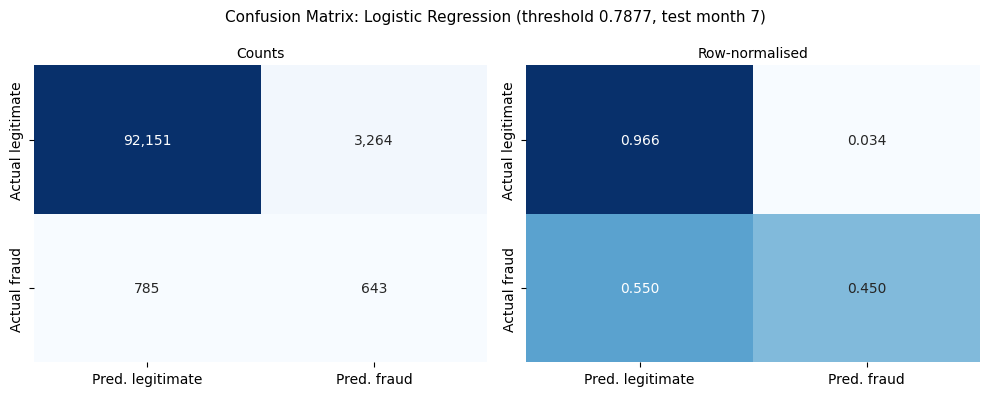

In [7]:
plot_confusion("Logistic Regression")

## 3. Random Forest

A bagging ensemble that constructs trees independently and averages them, in contrast to the sequential error-correction of the boosting models. Hyperparameters are selected by walk-forward search within the training window before the model is trained, calibrated and tested.

In [8]:
def build_rf(p):
    return Pipeline([("prep", preprocess_trees),
                     ("model", RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                                                      random_state=SEED, **p))])

rf_search = tune("Random Forest",
                 {"n_estimators": [200, 300], "max_depth": [8, 16], "min_samples_leaf": [5, 20]},
                 build_rf)

rf_params = {"n_estimators": int(rf_search.iloc[0]["n_estimators"]),
             "max_depth": int(rf_search.iloc[0]["max_depth"]),
             "min_samples_leaf": int(rf_search.iloc[0]["min_samples_leaf"])}

run_model("Random Forest", build_rf(rf_params))

[Random Forest] tuning 8 configurations via walk-forward validation
   n_estimators=200  max_depth=8  min_samples_leaf=5  -> PR-AUC: 0.1331
   n_estimators=200  max_depth=8  min_samples_leaf=20  -> PR-AUC: 0.1346
   n_estimators=200  max_depth=16  min_samples_leaf=5  -> PR-AUC: 0.1157
   n_estimators=200  max_depth=16  min_samples_leaf=20  -> PR-AUC: 0.1391
   n_estimators=300  max_depth=8  min_samples_leaf=5  -> PR-AUC: 0.1331
   n_estimators=300  max_depth=8  min_samples_leaf=20  -> PR-AUC: 0.1351
   n_estimators=300  max_depth=16  min_samples_leaf=5  -> PR-AUC: 0.1155
   n_estimators=300  max_depth=16  min_samples_leaf=20  -> PR-AUC: 0.1387
   BEST: {'n_estimators': 200.0, 'max_depth': 16.0, 'min_samples_leaf': 20.0, 'wf_pr_auc': 0.1390953550257524}

[Random Forest] trained on 794,989 rows in 229.2s
[Random Forest] validation: score range [0.0000, 0.9687] | threshold 0.4813 frozen at FPR 0.0500, TPR 0.4862
[Random Forest] test: TPR@5%FPR 0.5182 | PR-AUC 0.1689 | ROC-AUC 0.8771 | F1 

,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,Random Forest,0.5182,0.1689,0.8771,0.1588,0.4405,0.2334,0.9573,0.7028,0.0349,0.4813,629,3332,799,92083,229.2


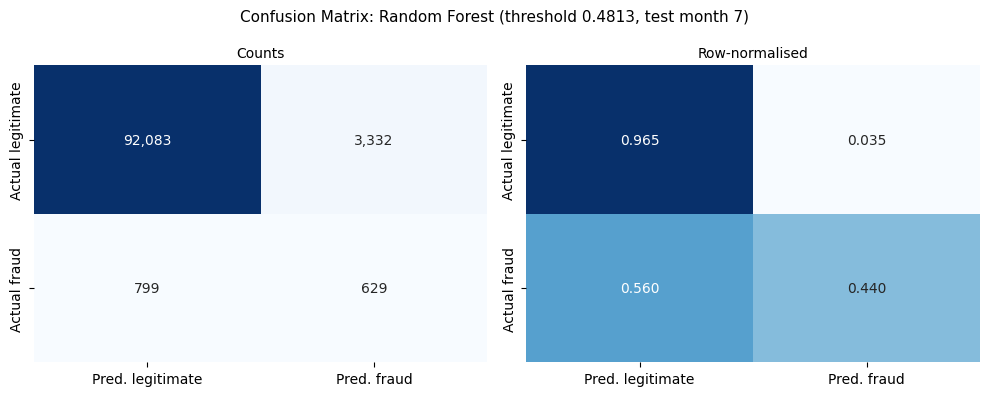

In [9]:
plot_confusion("Random Forest")

## 4. XGBoost

A gradient-boosted ensemble in which each tree sequentially corrects errors made by the preceding ensemble. Class imbalance is addressed using `scale_pos_weight`, calculated as the ratio of legitimate to fraudulent observations.

During walk-forward hyperparameter tuning, `scale_pos_weight` is recalculated separately from the training portion of each fold so that information from the corresponding validation month does not influence the class weighting. After hyperparameter selection, the final XGBoost model is fitted on months 0–5 using the class ratio calculated from that complete development-training partition.

In [10]:
# Full months 0-5 class ratio — used only for the final fitted XGBoost model
scale_pos = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"Final training-set scale_pos_weight: {scale_pos:.2f}\n")


def build_xgb(p, scale_weight):
    return Pipeline([
        ("prep", preprocess_trees),
        ("model", XGBClassifier(
            scale_pos_weight=scale_weight,
            n_jobs=-1,
            random_state=SEED,
            eval_metric="logloss",
            **p
        ))
    ])


def tune_xgb(grid):
    """Walk-forward XGBoost tuning using fold-specific class weighting and PR-AUC."""
    
    keys = list(grid.keys())
    combos = list(product(*grid.values()))
    rows = []

    print(
        f"[XGBoost] tuning {len(combos)} configurations "
        "via walk-forward validation"
    )

    for combo in combos:
        params = dict(zip(keys, combo))
        fold_scores = []

        for tr_m, va_m in WF_FOLDS:
            tr = train_months.isin(tr_m)
            va = train_months == va_m

            # Compute imbalance ratio from this fold's training data only
            y_fold_train = y_train[tr]

            fold_scale_pos = float(
                (y_fold_train == 0).sum() /
                (y_fold_train == 1).sum()
            )

            model = build_xgb(params, fold_scale_pos)

            model.fit(
                X_train[tr],
                y_fold_train
            )

            preds = model.predict_proba(
                X_train[va]
            )[:, 1]

            fold_scores.append(
                average_precision_score(
                    y_train[va],
                    preds
                )
            )

        score = float(np.mean(fold_scores))

        rows.append({
            **params,
            "wf_pr_auc": score
        })

        print(
            "   "
            + "  ".join(f"{k}={v}" for k, v in params.items())
            + f"  -> PR-AUC: {score:.4f}"
        )

    df = (
        pd.DataFrame(rows)
        .sort_values("wf_pr_auc", ascending=False)
        .reset_index(drop=True)
    )

    print(f"   BEST: {df.iloc[0].to_dict()}\n")

    return df


xgb_search = tune_xgb({
    "n_estimators": [300, 500],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1]
})


xgb_params = {
    "n_estimators": int(xgb_search.iloc[0]["n_estimators"]),
    "max_depth": int(xgb_search.iloc[0]["max_depth"]),
    "learning_rate": float(xgb_search.iloc[0]["learning_rate"])
}


# Final XGBoost is fitted on all development training months (0-5),
# so the class ratio is now legitimately calculated from all of y_train.
run_model(
    "XGBoost",
    build_xgb(xgb_params, scale_pos)
)

Final training-set scale_pos_weight: 96.53

[XGBoost] tuning 8 configurations via walk-forward validation
   n_estimators=300  max_depth=4  learning_rate=0.05  -> PR-AUC: 0.1869
   n_estimators=300  max_depth=4  learning_rate=0.1  -> PR-AUC: 0.1852
   n_estimators=300  max_depth=6  learning_rate=0.05  -> PR-AUC: 0.1748
   n_estimators=300  max_depth=6  learning_rate=0.1  -> PR-AUC: 0.1603
   n_estimators=500  max_depth=4  learning_rate=0.05  -> PR-AUC: 0.1876
   n_estimators=500  max_depth=4  learning_rate=0.1  -> PR-AUC: 0.1781
   n_estimators=500  max_depth=6  learning_rate=0.05  -> PR-AUC: 0.1669
   n_estimators=500  max_depth=6  learning_rate=0.1  -> PR-AUC: 0.1495
   BEST: {'n_estimators': 500.0, 'max_depth': 4.0, 'learning_rate': 0.05, 'wf_pr_auc': 0.18763892285350275}

[XGBoost] trained on 794,989 rows in 34.1s
[XGBoost] validation: score range [0.0005, 0.9982] | threshold 0.8068 frozen at FPR 0.0500, TPR 0.5214
[XGBoost] test: TPR@5%FPR 0.5616 | PR-AUC 0.2093 | ROC-AUC 0.8929 |

,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,XGBoost,0.5616,0.2093,0.8929,0.166,0.5091,0.2504,0.9551,0.7354,0.0383,0.8068,727,3652,701,91763,34.1


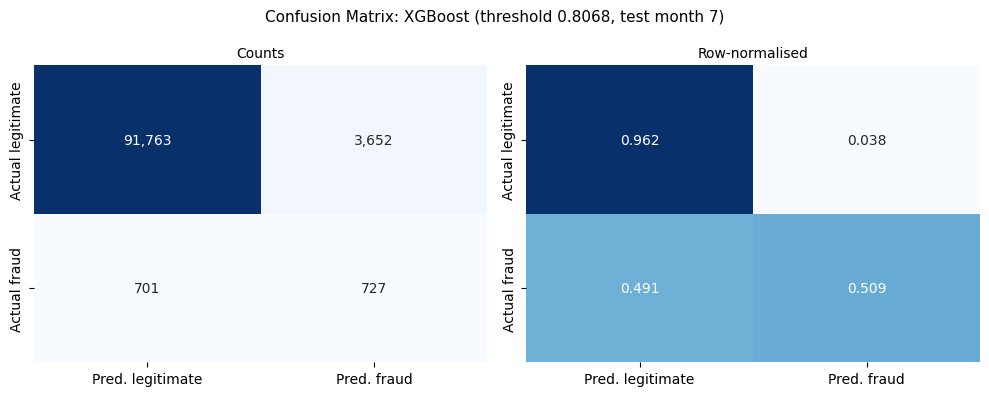

In [11]:
plot_confusion("XGBoost")

## 5. LightGBM

A second gradient-boosting implementation using leaf-wise growth and histogram-based splitting. Included both as a candidate model and as a base learner with a different inductive bias to XGBoost.

In [12]:
def build_lgbm(p):
    return Pipeline([("prep", preprocess_trees),
                     ("model", LGBMClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED,
                                              verbose=-1, **p))])

lgbm_search = tune("LightGBM",
                   {"n_estimators": [300, 500], "num_leaves": [15, 31], "learning_rate": [0.05, 0.1]},
                   build_lgbm)

lgbm_params = {"n_estimators": int(lgbm_search.iloc[0]["n_estimators"]),
               "num_leaves": int(lgbm_search.iloc[0]["num_leaves"]),
               "learning_rate": float(lgbm_search.iloc[0]["learning_rate"])}

run_model("LightGBM", build_lgbm(lgbm_params))

[LightGBM] tuning 8 configurations via walk-forward validation
   n_estimators=300  num_leaves=15  learning_rate=0.05  -> PR-AUC: 0.1856
   n_estimators=300  num_leaves=15  learning_rate=0.1  -> PR-AUC: 0.1827
   n_estimators=300  num_leaves=31  learning_rate=0.05  -> PR-AUC: 0.1853
   n_estimators=300  num_leaves=31  learning_rate=0.1  -> PR-AUC: 0.1698
   n_estimators=500  num_leaves=15  learning_rate=0.05  -> PR-AUC: 0.1847
   n_estimators=500  num_leaves=15  learning_rate=0.1  -> PR-AUC: 0.1793
   n_estimators=500  num_leaves=31  learning_rate=0.05  -> PR-AUC: 0.1825
   n_estimators=500  num_leaves=31  learning_rate=0.1  -> PR-AUC: 0.1547
   BEST: {'n_estimators': 300.0, 'num_leaves': 15.0, 'learning_rate': 0.05, 'wf_pr_auc': 0.18556491139820225}

[LightGBM] trained on 794,989 rows in 20.0s
[LightGBM] validation: score range [0.0014, 0.9941] | threshold 0.8101 frozen at FPR 0.0500, TPR 0.5221
[LightGBM] test: TPR@5%FPR 0.5728 | PR-AUC 0.2172 | ROC-AUC 0.8967 | F1 0.2472 | achieved 

,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,LightGBM,0.5728,0.2172,0.8967,0.1601,0.542,0.2472,0.9513,0.7497,0.0426,0.8101,774,4060,654,91355,20.0


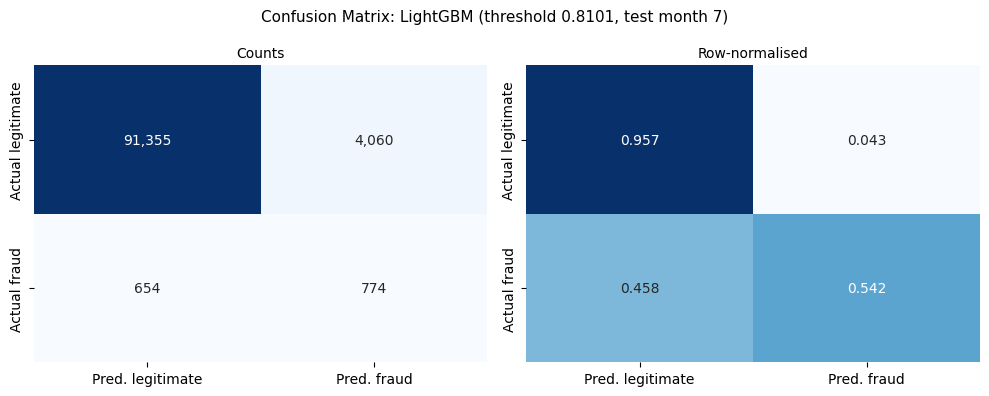

In [13]:
plot_confusion("LightGBM")

## 6. Stacking Ensemble - Primary Model

The principal model of this study combines three complementary base learners: XGBoost, LightGBM and Logistic Regression. XGBoost and LightGBM provide non-linear gradient-boosted tree representations, while Logistic Regression provides a structurally different linear representation.

Each base learner uses model-appropriate preprocessing. XGBoost and LightGBM use the tree preprocessing pipeline, whereas Logistic Regression uses the linear preprocessing pipeline. Class imbalance is addressed through `scale_pos_weight` for XGBoost and `class_weight="balanced"` for LightGBM and Logistic Regression.

The predicted probabilities from the three base learners are combined by a Logistic Regression meta-learner. Three-fold cross-validation (`cv=3`) is used within the stacking procedure to generate out-of-fold base-model predictions for training the meta-learner.

In [14]:
xgb_tuned = XGBClassifier(**xgb_params, scale_pos_weight=scale_pos, n_jobs=-1,
                          random_state=SEED, eval_metric="logloss")
lgbm_tuned = LGBMClassifier(**lgbm_params, class_weight="balanced", n_jobs=-1,
                            random_state=SEED, verbose=-1)
lr_base = Pipeline([
    ("prep", preprocess_linear),
    ("m", LogisticRegression(
        **lr_params,
        max_iter=1000,
        class_weight="balanced",
        random_state=SEED
    ))
])
stack = StackingClassifier(
    estimators=[("xgb", Pipeline([("prep", preprocess_trees), ("m", xgb_tuned)])),
                ("lgbm", Pipeline([("prep", preprocess_trees), ("m", lgbm_tuned)])),
                ("lr", lr_base)],
    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED),
    stack_method="predict_proba", cv=3, n_jobs=-1)

run_model("Stacking Ensemble", stack)

[Stacking Ensemble] trained on 794,989 rows in 222.8s
[Stacking Ensemble] validation: score range [0.0646, 0.9522] | threshold 0.8651 frozen at FPR 0.0500, TPR 0.5186
[Stacking Ensemble] test: TPR@5%FPR 0.5770 | PR-AUC 0.2161 | ROC-AUC 0.8970 | F1 0.2522 | achieved FPR 0.0391


,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,Stacking Ensemble,0.577,0.2161,0.897,0.1663,0.5217,0.2522,0.9544,0.7413,0.0391,0.8651,745,3735,683,91680,222.8


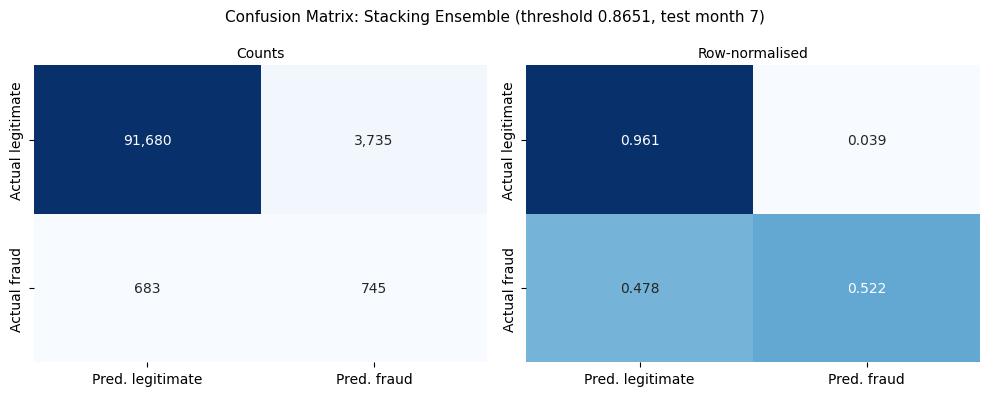

In [15]:
plot_confusion("Stacking Ensemble")

### 6.1 Base-Learner Prediction Diversity

To examine whether the base learners provide complementary predictive information, pairwise correlations are calculated between the test-set probability predictions produced by XGBoost, LightGBM and Logistic Regression. Lower correlation between learners may indicate greater diversity in their predictions, whereas very high correlation suggests that the models are capturing largely similar patterns. This analysis provides supporting evidence for assessing whether the inclusion of structurally different learners contributes useful information to the stacking ensemble.

In [16]:
meta = fitted_models["Stacking Ensemble"]
coefs = meta.final_estimator_.coef_[0]

print("Meta-learner (logistic regression) over base-model probabilities\n")

for n, c in zip([n for n, _ in meta.estimators], coefs):
    print(
        f"  {n:8s} coefficient = {c:+.4f}   "
        f"({abs(c)/np.abs(coefs).sum()*100:5.1f}% of absolute coefficient magnitude)"
    )

print(f"  {'intercept':8s} = {meta.final_estimator_.intercept_[0]:+.4f}")

base_predictions = pd.DataFrame({
    "XGBoost": meta.named_estimators_["xgb"].predict_proba(X_test)[:, 1],
    "LightGBM": meta.named_estimators_["lgbm"].predict_proba(X_test)[:, 1],
    "Logistic Regression": meta.named_estimators_["lr"].predict_proba(X_test)[:, 1]
})

print("\nCorrelation between fitted base learners' test predictions:")
display(base_predictions.corr())

Meta-learner (logistic regression) over base-model probabilities

  xgb      coefficient = +1.4732   ( 25.9% of absolute coefficient magnitude)
  lgbm     coefficient = +3.1127   ( 54.6% of absolute coefficient magnitude)
  lr       coefficient = +1.1127   ( 19.5% of absolute coefficient magnitude)
  intercept = -2.6798

Correlation between fitted base learners' test predictions:


,XGBoost,LightGBM,Logistic Regression
XGBoost,1.000000,0.977134,0.911076
LightGBM,0.977134,1.000000,0.921793
Logistic Regression,0.911076,0.921793,1.000000


## 7. Ensemble Ablation

An alternative stacking composition is evaluated to determine whether adding Random Forest to the primary XGBoost–LightGBM–Logistic Regression ensemble provides additional predictive value.

The resulting four-learner ensemble is evaluated using the same training, validation-threshold calibration and held-out test protocol as the primary stacking model. This allows the additional predictive contribution of Random Forest to be considered alongside the associated increase in computational complexity.

In [17]:
rf_tuned = RandomForestClassifier(
    **rf_params,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED
)

stack_rf = StackingClassifier(
    estimators=[
        ("xgb", Pipeline([("prep", preprocess_trees), ("m", xgb_tuned)])),
        ("lgbm", Pipeline([("prep", preprocess_trees), ("m", lgbm_tuned)])),
        ("lr", lr_base),
        ("rf", Pipeline([("prep", preprocess_trees), ("m", rf_tuned)]))
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=SEED
    ),
    stack_method="predict_proba",
    cv=3,
    n_jobs=-1
)

run_model("Stack + Random Forest", stack_rf)

[Stack + Random Forest] trained on 794,989 rows in 972.3s
[Stack + Random Forest] validation: score range [0.0643, 0.9537] | threshold 0.8658 frozen at FPR 0.0500, TPR 0.5179
[Stack + Random Forest] test: TPR@5%FPR 0.5763 | PR-AUC 0.2152 | ROC-AUC 0.8969 | F1 0.2513 | achieved FPR 0.0392


,Model,TPR@5%FPR,PR-AUC,ROC-AUC,Precision,Recall,F1,Accuracy,Balanced Acc,Achieved FPR,Threshold,TP,FP,FN,TN,Train time (s)
0,Stack + Random Forest,0.5763,0.2152,0.8969,0.1657,0.5196,0.2513,0.9543,0.7402,0.0392,0.8658,742,3736,686,91679,972.3


## 8. Model Comparison

### 8.1 Comprehensive Results Table

All models on the test month at their individually frozen thresholds, separated into threshold-free metrics, operating-point metrics, and raw confusion-matrix counts.

In [18]:
results_df = pd.DataFrame(results).sort_values("TPR@5%FPR", ascending=False).reset_index(drop=True)
results_df.to_csv("results_all_models.csv", index=False)

print("DISCRIMINATION AND FIXED-FPR METRICS")
print(results_df[["Model", "TPR@5%FPR", "PR-AUC", "ROC-AUC"]].to_string(index=False))
print("\nOPERATING-POINT METRICS (at frozen threshold)")
print(results_df[["Model", "Threshold", "Achieved FPR", "Precision", "Recall",
                  "F1", "Accuracy", "Balanced Acc"]].to_string(index=False))
print("\nCONFUSION MATRIX COUNTS AND COST")
print(results_df[["Model", "TP", "FP", "FN", "TN", "Train time (s)"]].to_string(index=False))

DISCRIMINATION AND FIXED-FPR METRICS
                 Model  TPR@5%FPR  PR-AUC  ROC-AUC
     Stacking Ensemble     0.5770  0.2161   0.8970
 Stack + Random Forest     0.5763  0.2152   0.8969
              LightGBM     0.5728  0.2172   0.8967
               XGBoost     0.5616  0.2093   0.8929
   Logistic Regression     0.5336  0.1849   0.8869
         Random Forest     0.5182  0.1689   0.8771
Dummy (majority class)     0.0500  0.0147   0.5000

OPERATING-POINT METRICS (at frozen threshold)
                 Model  Threshold  Achieved FPR  Precision  Recall     F1  Accuracy  Balanced Acc
     Stacking Ensemble     0.8651        0.0391     0.1663  0.5217 0.2522    0.9544        0.7413
 Stack + Random Forest     0.8658        0.0392     0.1657  0.5196 0.2513    0.9543        0.7402
              LightGBM     0.8101        0.0426     0.1601  0.5420 0.2472    0.9513        0.7497
               XGBoost     0.8068        0.0383     0.1660  0.5091 0.2504    0.9551        0.7354
   Logistic Regres

**How the metrics should be compared.** TPR at 5% FPR compares all models at the same false-positive operating point and therefore provides the primary fixed-FPR comparison. PR-AUC and ROC-AUC instead summarise ranking performance across a range of decision thresholds.

Precision, recall, F1, accuracy, balanced accuracy and the TP/FP/FN/TN counts are reported at each model's validation-selected frozen threshold. Because these thresholds were calibrated on month 6 and transferred unchanged to month 7, the achieved false-positive rates may differ between models. These operating-point metrics should therefore be interpreted together with each model's achieved FPR rather than treated as directly matched-threshold rankings.

### 8.2 Discrimination and Fixed-FPR Performance Comparison

The figure compares TPR at 5% FPR with PR-AUC and ROC-AUC. TPR at 5% FPR measures detection performance at the predefined false-positive operating point, whereas PR-AUC and ROC-AUC summarise ranking performance across thresholds. The large difference between ROC-AUC and PR-AUC also illustrates the importance of precision-recall analysis under the severe class imbalance present in the test month.

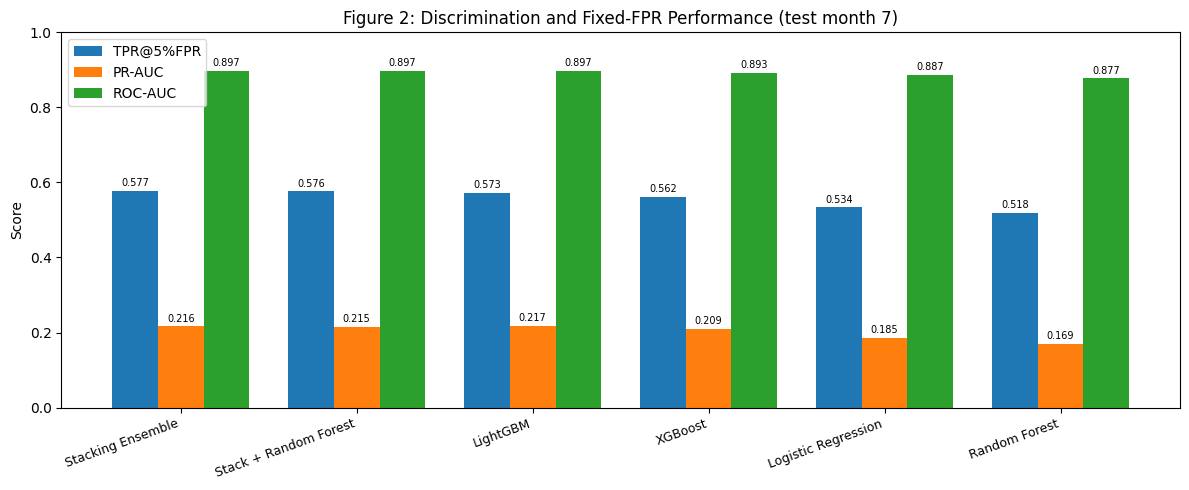

In [19]:
plot_df = results_df[results_df["Model"] != "Dummy (majority class)"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(plot_df)), 0.26
for i, m in enumerate(["TPR@5%FPR", "PR-AUC", "ROC-AUC"]):
    bars = ax.bar(x + (i - 1) * w, plot_df[m], w, label=m)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x); ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.0)
ax.set_title( "Figure 2: Discrimination and Fixed-FPR Performance (test month 7)")
ax.legend()
plt.tight_layout()
plt.savefig("fig2_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.3 Operating-Point Metric Comparison

Precision, recall, F1 and balanced accuracy are reported at each model's validation-selected frozen threshold. The low fraud prevalence in the test month places substantial downward pressure on precision because even a relatively small false-positive rate can produce many false alerts relative to the number of fraudulent applications. Precision nevertheless remains model-dependent and should therefore be considered together with recall and achieved false-positive rate.

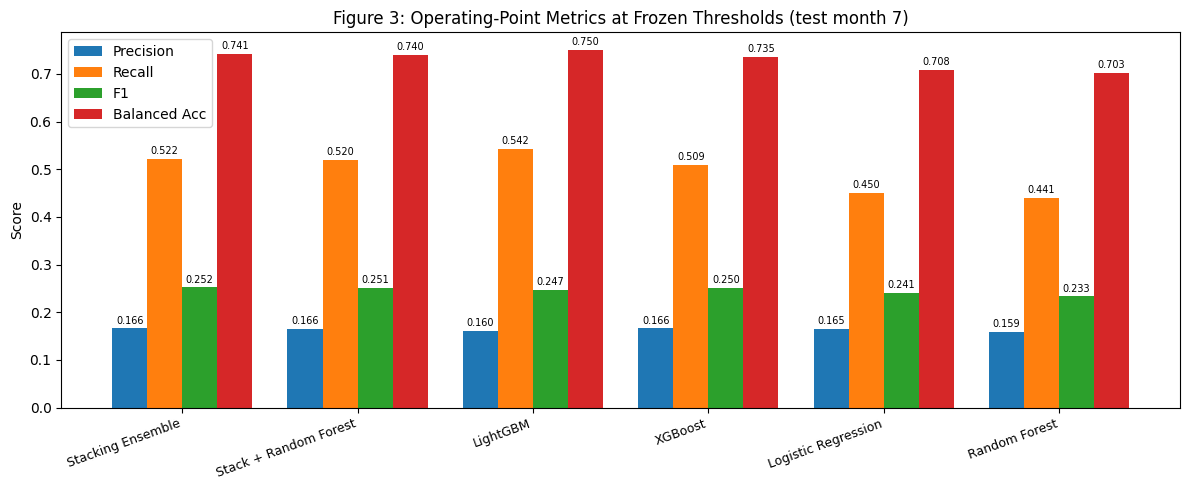

In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(plot_df)), 0.2
for i, m in enumerate(["Precision", "Recall", "F1", "Balanced Acc"]):
    bars = ax.bar(x + (i - 1.5) * w, plot_df[m], w, label=m)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x); ax.set_xticklabels(plot_df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Figure 3: Operating-Point Metrics at Frozen Thresholds (test month 7)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_operating_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.4 ROC and Precision-Recall Curves

The full trade-off surface for every model. The dotted vertical line marks the 5% FPR operating point at which the primary metric is read.

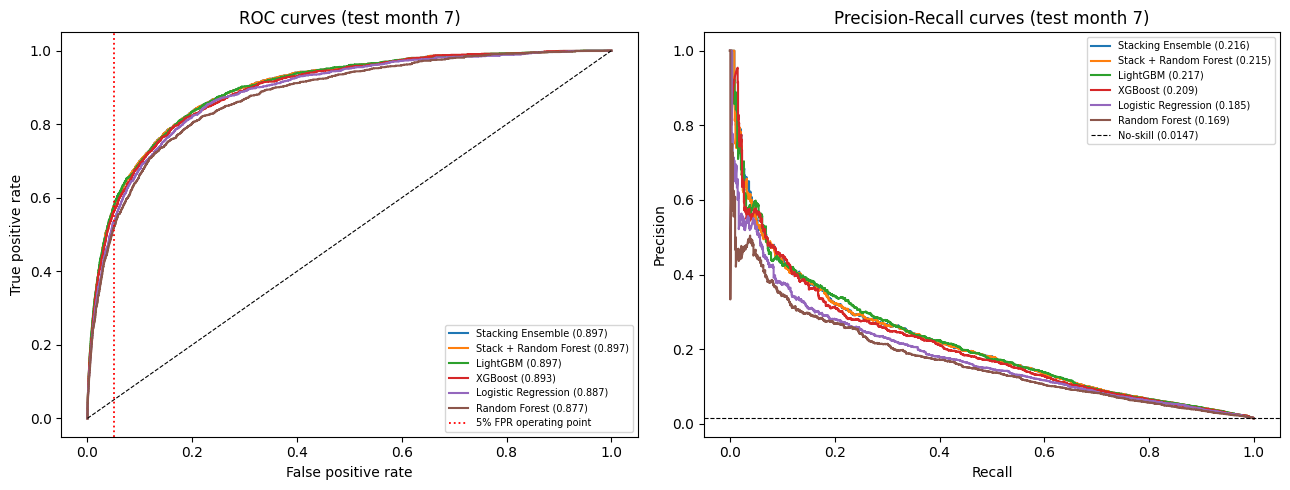

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for nm in plot_df["Model"]:
    s = test_scores_store[nm]
    f, t, _ = roc_curve(y_test, s)
    ax1.plot(f, t, linewidth=1.5, label=f"{nm} ({roc_auc_score(y_test, s):.3f})")
    p, r, _ = precision_recall_curve(y_test, s)
    ax2.plot(r, p, linewidth=1.5, label=f"{nm} ({average_precision_score(y_test, s):.3f})")

ax1.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax1.axvline(0.05, color="red", linestyle=":", linewidth=1.3, label="5% FPR operating point")
ax1.set_xlabel("False positive rate"); ax1.set_ylabel("True positive rate")
ax1.set_title("ROC curves (test month 7)"); ax1.legend(fontsize=7, loc="lower right")

ax2.axhline(y_test.mean(), color="k", linestyle="--", linewidth=0.8, label=f"No-skill ({y_test.mean():.4f})")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curves (test month 7)"); ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig("fig4_roc_pr_curves.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.5 Confusion Matrices Side by Side

All models at their frozen thresholds, permitting direct comparison of error composition.

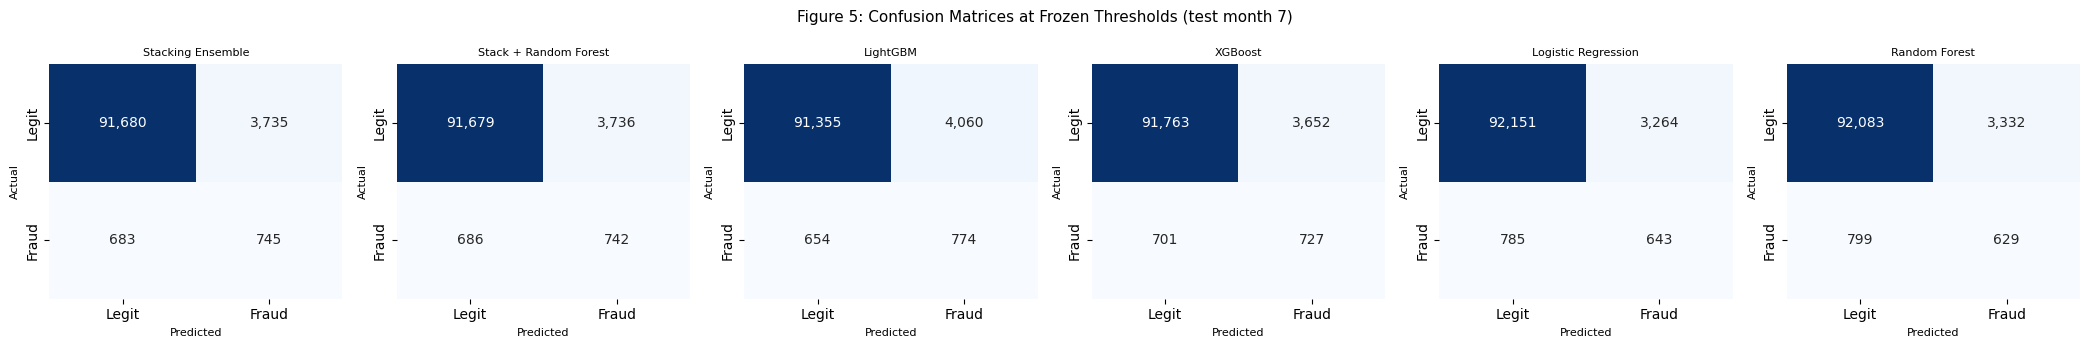

In [22]:
names = list(plot_df["Model"])
fig, axes = plt.subplots(1, len(names), figsize=(3.5 * len(names), 3.5))

for ax, nm in zip(np.atleast_1d(axes), names):
    cm = confusion_matrix(y_test, (test_scores_store[nm] >= thresholds[nm]).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(nm, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=8); ax.set_ylabel("Actual", fontsize=8)

fig.suptitle("Figure 5: Confusion Matrices at Frozen Thresholds (test month 7)", fontsize=11)
plt.tight_layout()
plt.savefig("fig5_confusion_all.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Save Artefacts

Persists the fitted models, frozen thresholds, prediction scores and tuning results, so Notebook 3 performs its statistical, explainability, fairness and robustness analyses without retraining.

In [23]:
# Remove obsolete artefact from the previous stacking design
old_stack_file = "model_stack_+_logreg.pkl"
if os.path.exists(old_stack_file):
    os.remove(old_stack_file)

# Save fitted models
for nm, model in fitted_models.items():
    joblib.dump(model, f"model_{nm.replace(' ', '_').lower()}.pkl")

# Save thresholds and probability scores
joblib.dump(thresholds, "frozen_thresholds.pkl")
joblib.dump(test_scores_store, "test_scores.pkl")
joblib.dump(val_scores_store, "val_scores.pkl")

# Save tuning results
joblib.dump({
    "lr": lr_search,
    "rf": rf_search,
    "xgb": xgb_search,
    "lgbm": lgbm_search
}, "tuning_results.pkl")

# Save selected hyperparameters
joblib.dump({
    "lr": lr_params,
    "rf": rf_params,
    "xgb": xgb_params,
    "lgbm": lgbm_params,
    "scale_pos": scale_pos
}, "best_params.pkl")

for f in sorted(f for f in os.listdir(".") if f.endswith((".pkl", ".csv", ".png"))):
    print(f"{f:44s} {os.path.getsize(f)/1e6:7.2f} MB")

best_params.pkl                                 0.00 MB
cm_lightgbm.png                                 0.06 MB
cm_logistic_regression.png                      0.07 MB
cm_random_forest.png                            0.07 MB
cm_stacking_ensemble.png                        0.07 MB
cm_xgboost.png                                  0.07 MB
fig2_model_comparison.png                       0.12 MB
fig3_operating_metrics.png                      0.13 MB
fig4_roc_pr_curves.png                          0.25 MB
fig5_confusion_all.png                          0.09 MB
frozen_thresholds.pkl                           0.00 MB
model_lightgbm.pkl                              0.56 MB
model_logistic_regression.pkl                   0.01 MB
model_random_forest.pkl                        88.79 MB
model_stack_+_random_forest.pkl                90.25 MB
model_stacking_ensemble.pkl                     1.44 MB
model_xgboost.pkl                               0.86 MB
results_all_models.csv                          

## 10. Summary

All reported models follow an identical evaluation protocol: models are fitted using months 0–5, decision thresholds are calibrated on month 6 at a target 5% false-positive rate and then transferred unchanged to the held-out month-7 test set

Points to note when interpreting Section 8:

- The dummy classifier's accuracy relative to its recall establishes that accuracy is uninformative at this prevalence.
- The margin between the tree-based models and logistic regression indicates whether non-linear modelling is justified.
- The margin between the stacking ensemble and the strongest single model indicates whether stacking specifically is justified. Section 6.1 provides the diagnostic mechanism through the meta-learner coefficients and base-learner correlation; Notebook 3 assesses these differences formally using paired bootstrap confidence intervals for paired model-performance differences.
- Achieved test FPR should be compared against the 5% target: divergence quantifies residual distribution shift between the calibration and test periods.
- With 1,428 fraud cases in the test month, differences of less than roughly one percentage point in TPR should not be treated as meaningful without the confidence intervals reported in Notebook 3.